# InCommodities Case Crunch 2026 - Feature Engineering Validation
This notebook visualizes and structurally validates the stateless feature engineering functions built in `src/features.py` to ensure mathematical accuracy and absence of lookahead bias prior to model training.

### Task 1: Setup & Ingestion
Load data using `load_competition_data()`. The underlying function automatically performs the causal forward-fill for sparse daily variables based on `config.yaml`.

**Physical Grid Constants & Sources:**
* **FR Nuclear Capacity (61,400 MW):** France operates 56 reactors with a total installed capacity of roughly 61.4 GW. (Source: RTE / World Nuclear Association).
* **UK Nuclear Capacity (5,800 MW):** The UK's active nuclear fleet capacity is roughly 5.8 GW. (Source: National Grid ESO / World Nuclear Association).
* **CCGT Efficiency (50%):** A modern Combined Cycle Gas Turbine has an average thermal efficiency of 50%, meaning it requires 2 MWh of gas to produce 1 MWh of electricity.
* **Emission Factor (0.202 tCO2/MWh):** Burning natural gas emits approximately 0.202 tonnes of CO2 per MWh of thermal energy.

In [14]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.feature_selection import mutual_info_regression

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

sys.path.append(os.path.abspath('..'))
from src.data_ingestion import load_competition_data
from src.features import apply_full_feature_engineering

print("Loading dataset...")
df = load_competition_data(config_path="../config.yaml")
print("Applying full feature engineering...")
df = apply_full_feature_engineering(df)
print(f"Final Engineered shape: {df.shape}")


Loading dataset...
Applying full feature engineering...
Final Engineered shape: (17544, 144)


### Task 2: Visualizing Residual Load
Validating `ResLoad = load_f - (solar_f + wind_f)` for France.

Residual Load Describe (France):
count    17544.000000
mean     41612.677595
std      10413.957012
min      14523.330000
25%      34424.472500
50%      39635.565000
75%      46352.985000
max      78562.830000
Name: fr_res_load, dtype: float64

If min >= 0, our math is solid.


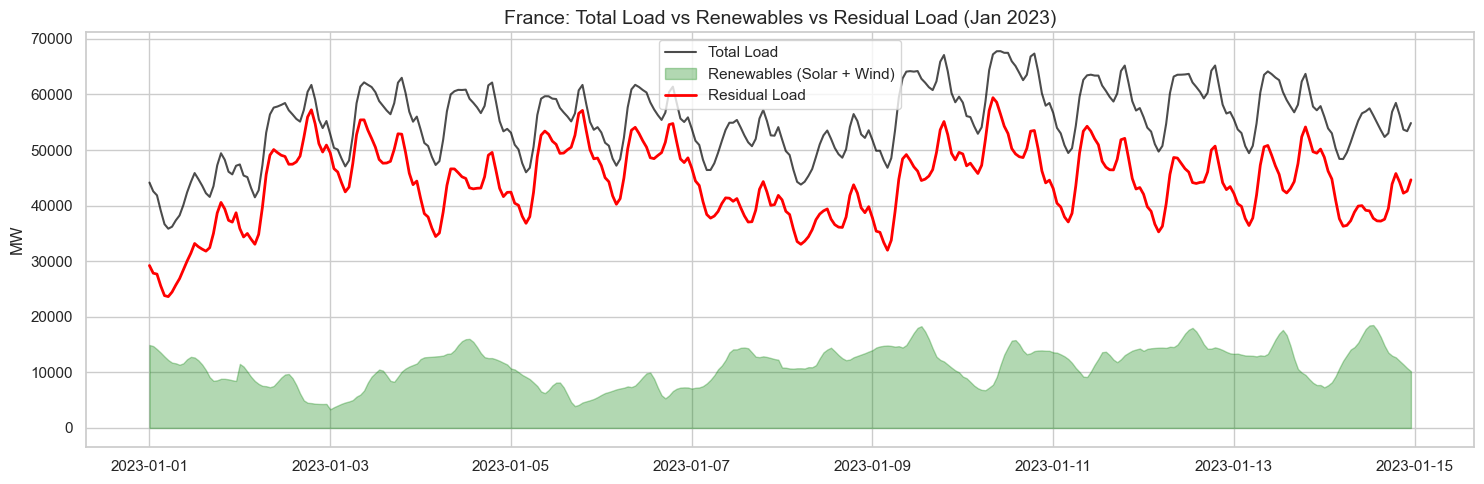

In [15]:
print("Residual Load Describe (France):")
print(df['fr_res_load'].describe())
print("\nIf min >= 0, our math is solid.")
# 2-Week Slice: January 2023
slice_2w = df.loc['2023-01-01':'2023-01-14']
plt.figure(figsize=(15, 5))
plt.plot(slice_2w.index, slice_2w['fr_load_f'], label='Total Load', color='black', alpha=0.7)
plt.fill_between(slice_2w.index, 0, slice_2w['fr_solar_f'] + slice_2w['fr_wind_f'], 
                 label='Renewables (Solar + Wind)', color='green', alpha=0.3)
plt.plot(slice_2w.index, slice_2w['fr_res_load'], label='Residual Load', color='red', linewidth=2)
plt.title('France: Total Load vs Renewables vs Residual Load (Jan 2023)', fontsize=14)
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.show()

### Task 3: Visualizing the Thermal Floor
Validating the proxy marginal cost: `Cost_Thermal = (gas_price / 0.5) + (emission_price * 0.202 / 0.5)`.

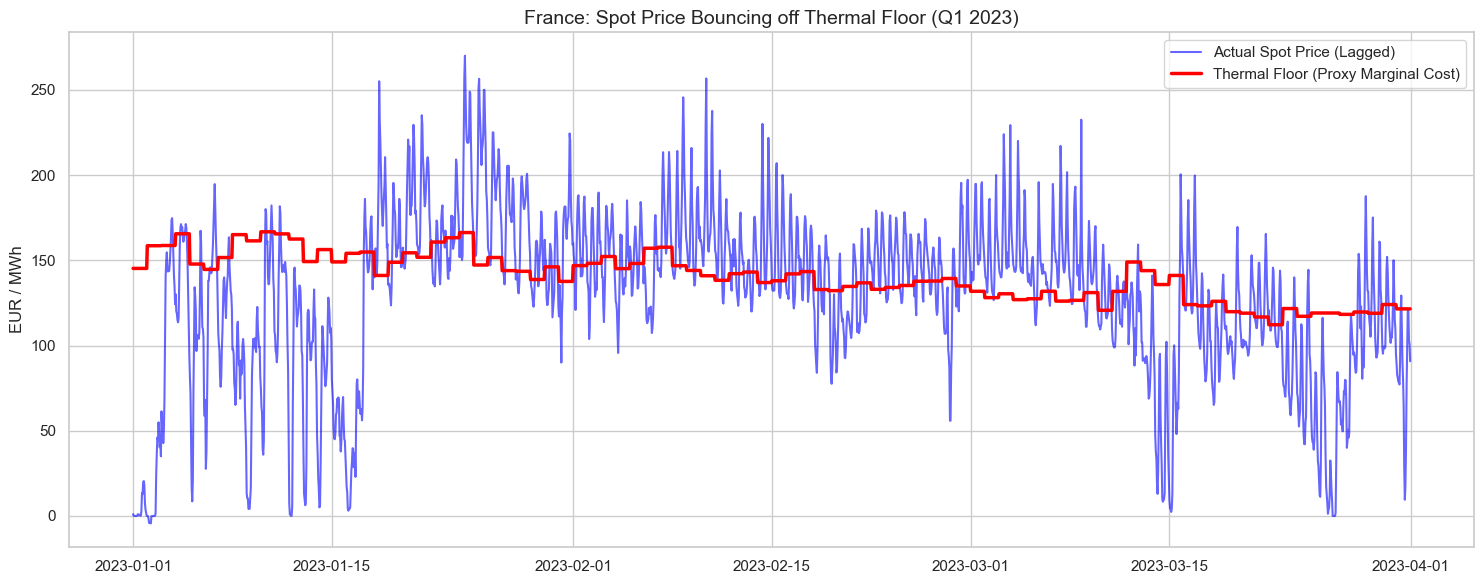

In [16]:
# 3-Month Slice: Jan - Mar 2023
slice_3m = df.loc['2023-01-01':'2023-03-31']
plt.figure(figsize=(15, 6))
plt.plot(slice_3m.index, slice_3m['fr_spot_la'], label='Actual Spot Price (Lagged)', color='blue', alpha=0.6)
plt.plot(slice_3m.index, slice_3m['fr_thermal_floor'], label='Thermal Floor (Proxy Marginal Cost)', color='red', linewidth=2.5)
plt.title('France: Spot Price Bouncing off Thermal Floor (Q1 2023)', fontsize=14)
plt.ylabel('EUR / MWh')
plt.legend()
plt.tight_layout()
plt.show()

### Task 4: Visualizing Interconnector Congestion (Viking Link)
Validating `ATC_Ratio` and the boolean online mask handling missing rows.

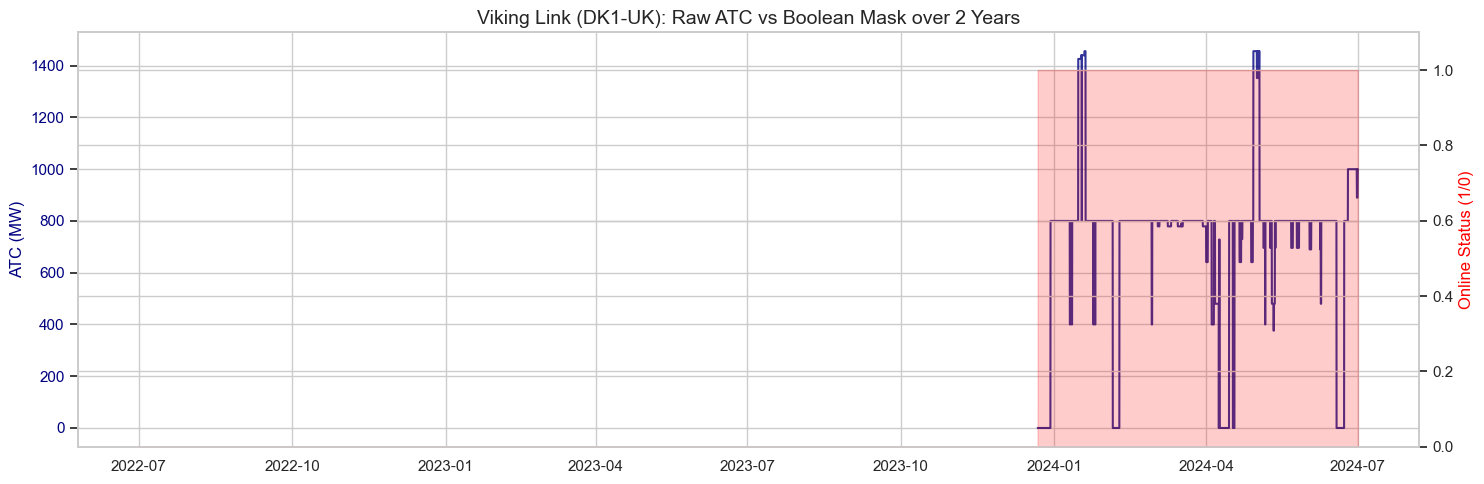

In [17]:
fig, ax1 = plt.subplots(figsize=(15, 5))
ax1.plot(df.index, df['atc_dk1-uk_f'], color='navy', label='Raw ATC (Viking Link)', alpha=0.8)
ax1.set_ylabel('ATC (MW)', color='navy')
ax1.tick_params(axis='y', labelcolor='navy')
ax2 = ax1.twinx()
ax2.fill_between(df.index, 0, df['is_atc_dk1-uk_f_online'], color='red', alpha=0.2, label='is_online Mask')
ax2.set_ylabel('Online Status (1/0)', color='red')
ax2.set_ylim(0, 1.1)
plt.title('Viking Link (DK1-UK): Raw ATC vs Boolean Mask over 2 Years', fontsize=14)
fig.tight_layout()
plt.show()

### Task 5: Visualizing Calendar & Weekly Periodicity
Proving the weekend price drop and the strong 168-hour lag correlation.

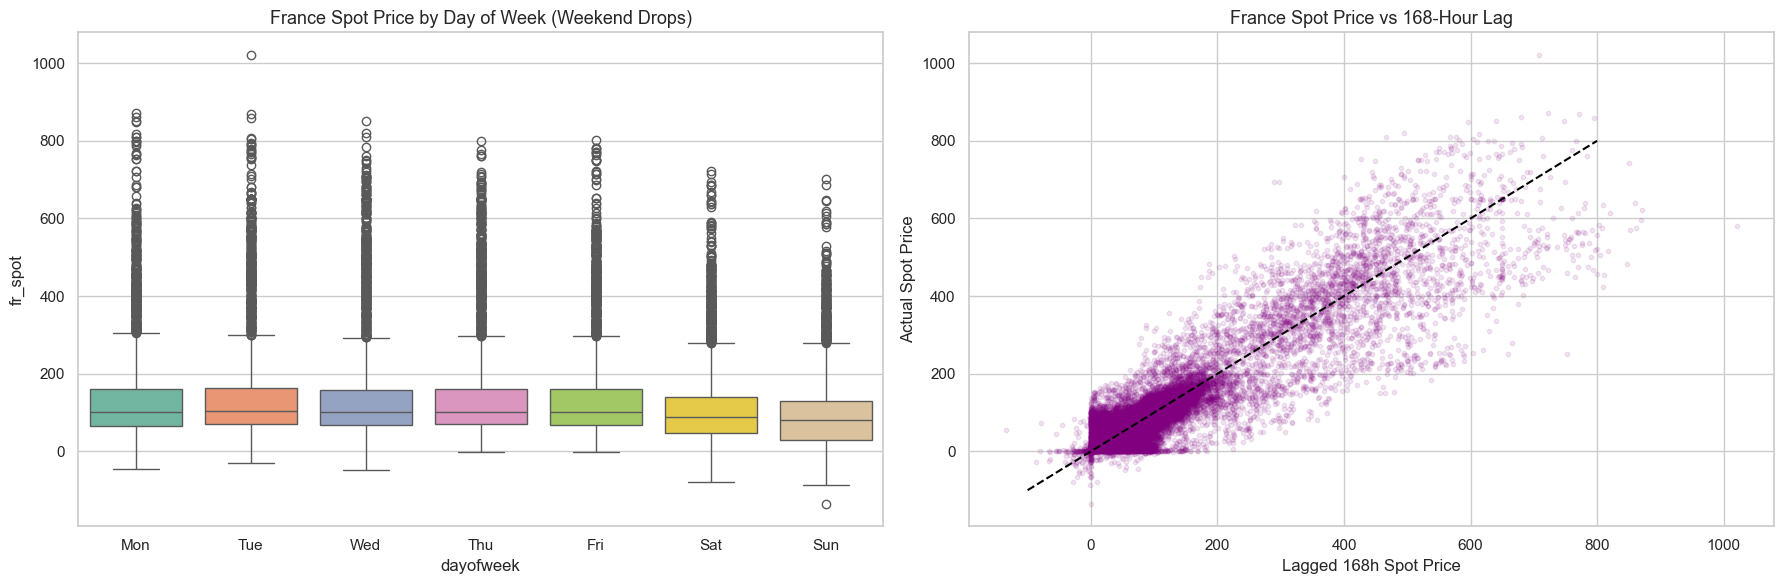

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
# Boxplot by Day of Week (0=Monday, 6=Sunday)
sns.boxplot(ax=axes[0], data=df, x='dayofweek', y='fr_spot', palette='Set2')
axes[0].set_title('France Spot Price by Day of Week (Weekend Drops)', fontsize=13)
axes[0].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
# Scatter: Actual vs 168h Lag
axes[1].scatter(df['fr_spot_la_lag_168'], df['fr_spot'], alpha=0.1, color='purple', s=10)
axes[1].plot([-100, 800], [-100, 800], color='black', linestyle='--') # Identity line
axes[1].set_title('France Spot Price vs 168-Hour Lag', fontsize=13)
axes[1].set_xlabel('Lagged 168h Spot Price')
axes[1].set_ylabel('Actual Spot Price')
plt.tight_layout()
plt.show()

### Task 6: Visualizing Nuclear Shortfall & Volatility
Aligning extreme price behavior with nuclear capacity deficits.

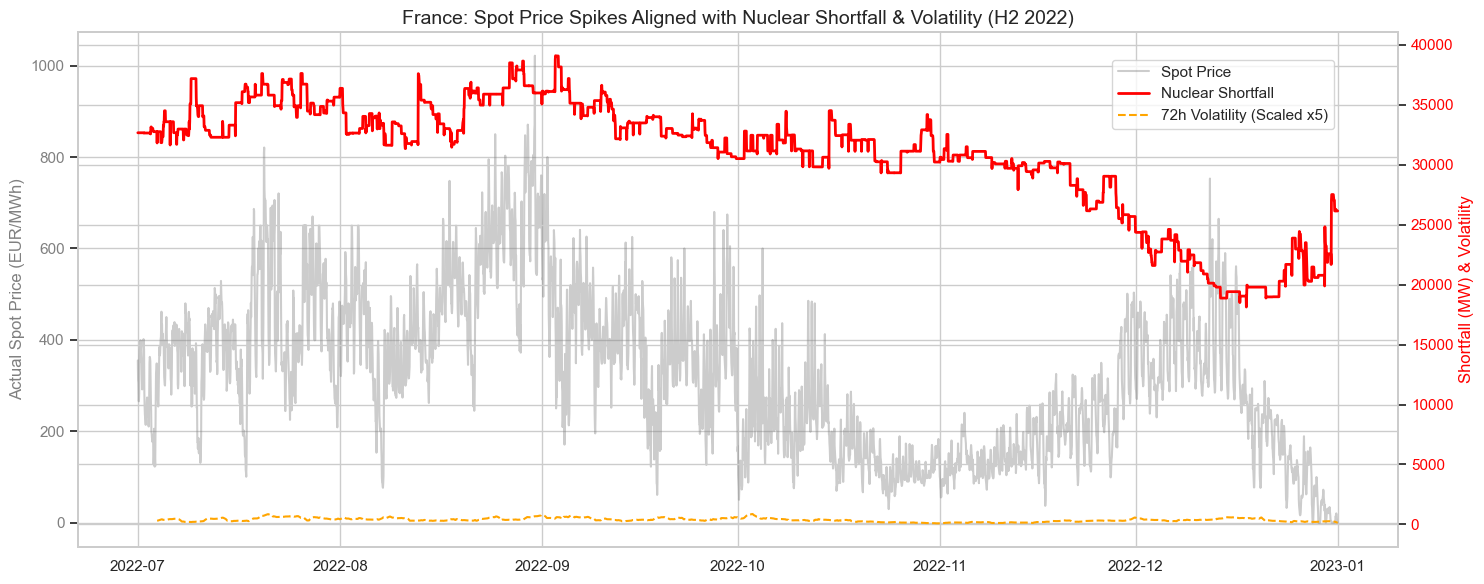

In [19]:
slice_6m = df.loc['2022-07-01':'2022-12-31'] # Winter 2022 stress
fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(slice_6m.index, slice_6m['fr_spot'], color='gray', alpha=0.4, label='Spot Price')
ax1.set_ylabel('Actual Spot Price (EUR/MWh)', color='gray')
ax1.tick_params(axis='y', labelcolor='gray')
ax2 = ax1.twinx()
ax2.plot(slice_6m.index, slice_6m['fr_nuclear_shortfall'], color='red', linewidth=2, label='Nuclear Shortfall')
ax2.plot(slice_6m.index, slice_6m['fr_spot_la_vol_72h'] * 5, color='orange', linestyle='--', label='72h Volatility (Scaled x5)')
ax2.set_ylabel('Shortfall (MW) & Volatility', color='red')
ax2.tick_params(axis='y', labelcolor='red')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.title('France: Spot Price Spikes Aligned with Nuclear Shortfall & Volatility (H2 2022)', fontsize=14)
fig.tight_layout()
plt.show()

### Task 5: Visualizing Heavy-Tail Compression (asinh)
Validating how `np.arcsinh()` smoothly compresses the right-tail kurtosis while preserving negative price structures for UK spot prices.

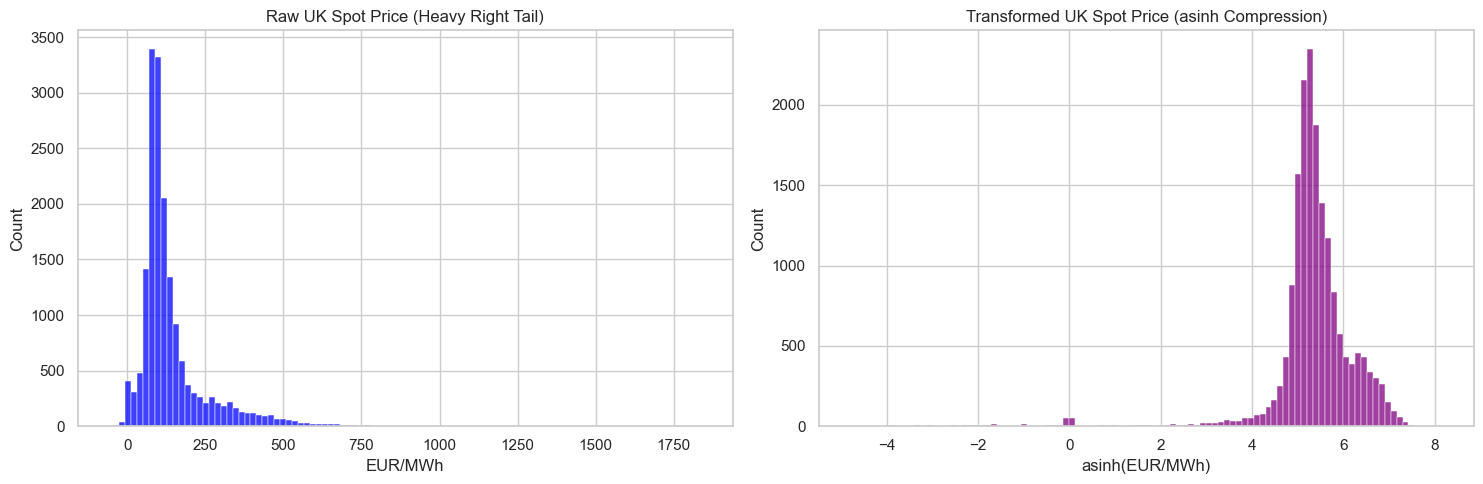

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['uk_spot_la'].dropna(), bins=100, ax=axes[0], color='blue')
axes[0].set_title('Raw UK Spot Price (Heavy Right Tail)')
axes[0].set_xlabel('EUR/MWh')
sns.histplot(df['uk_spot_la_asinh'].dropna(), bins=100, ax=axes[1], color='purple')
axes[1].set_title('Transformed UK Spot Price (asinh Compression)')
axes[1].set_xlabel('asinh(EUR/MWh)')
plt.tight_layout()
plt.show()


### Task 6: Visualizing the 3-Hour Residual Ramps
Comparing a 1-week winter slice (January 2023) of France's absolute residual load vs the engineered 3-hour ramp metric.

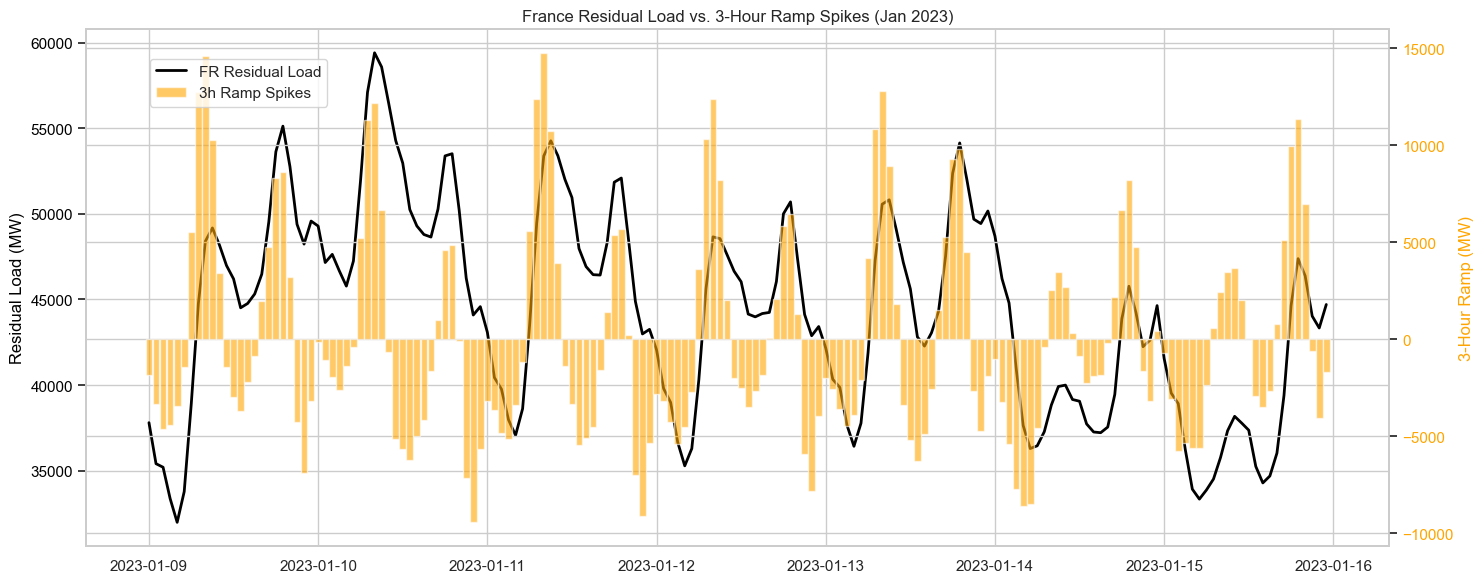

In [23]:
start_dt = '2023-01-09'
end_dt = '2023-01-15'
df_slice = df.loc[start_dt:end_dt]
fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(df_slice.index, df_slice['fr_res_load'], color='black', linewidth=2, label='FR Residual Load')
ax1.set_ylabel('Residual Load (MW)', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax2 = ax1.twinx()
ax2.bar(df_slice.index, df_slice['fr_res_load_ramp_3h'], color='orange', alpha=0.6, width=0.04, label='3h Ramp Spikes')
ax2.set_ylabel('3-Hour Ramp (MW)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
plt.title('France Residual Load vs. 3-Hour Ramp Spikes (Jan 2023)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1,0.9))
plt.tight_layout()
plt.show()


### Task 7: Visualizing Scarcity & Security Margins
Dual-axis tracking of France's Security Margin against the realized spot price over a two-month winter period, highlighting extreme price convexity near zero capacity.

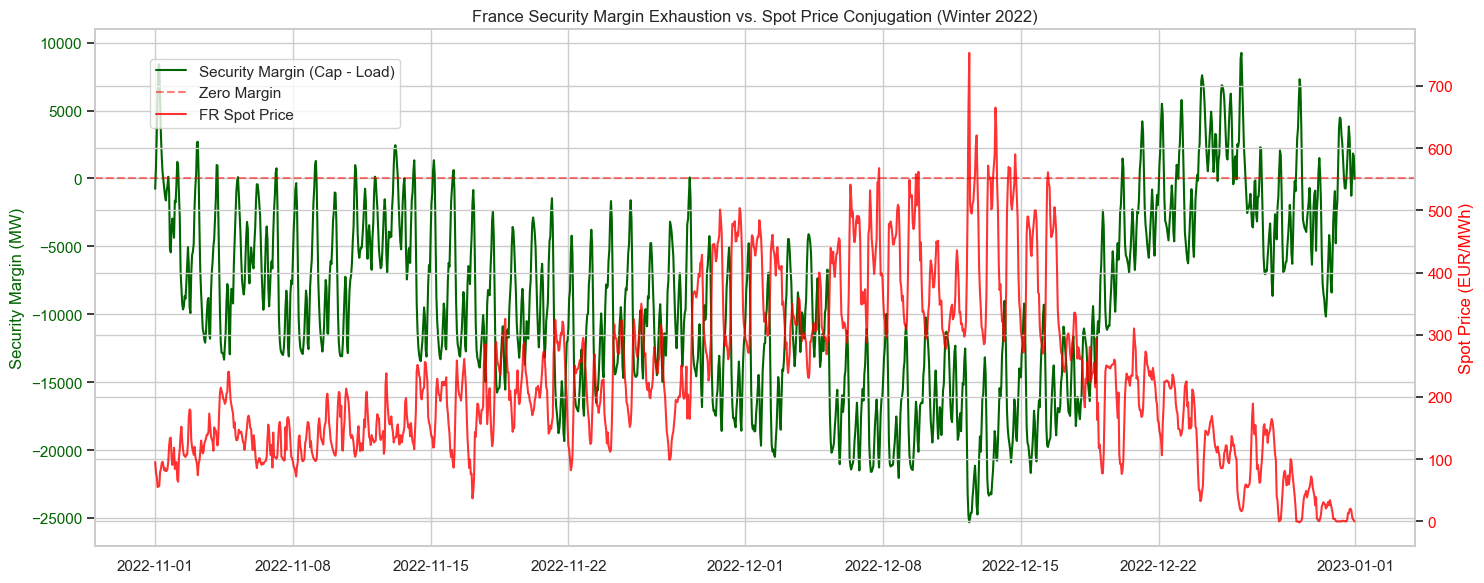

In [24]:
start_dt = '2022-11-01'
end_dt = '2022-12-31'
df_slice = df.loc[start_dt:end_dt]
fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(df_slice.index, df_slice['fr_security_margin'], color='darkgreen', linewidth=1.5, label='Security Margin (Cap - Load)')
ax1.set_ylabel('Security Margin (MW)', color='darkgreen')
ax1.tick_params(axis='y', labelcolor='darkgreen')
ax1.axhline(0, color='red', linestyle='--', alpha=0.5, label='Zero Margin')
ax2 = ax1.twinx()
ax2.plot(df_slice.index, df_slice['fr_spot'], color='red', alpha=0.8, linewidth=1.5, label='FR Spot Price')
ax2.set_ylabel('Spot Price (EUR/MWh)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
plt.title('France Security Margin Exhaustion vs. Spot Price Conjugation (Winter 2022)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1,0.9))
plt.tight_layout()
plt.show()


### Task 8: Visualizing 14-Day Rolling Z-Scores
Assessing how structured rolling Z-scores normalize the underlying seasonal load increase, spanning from Summer (July) into early Winter (December).

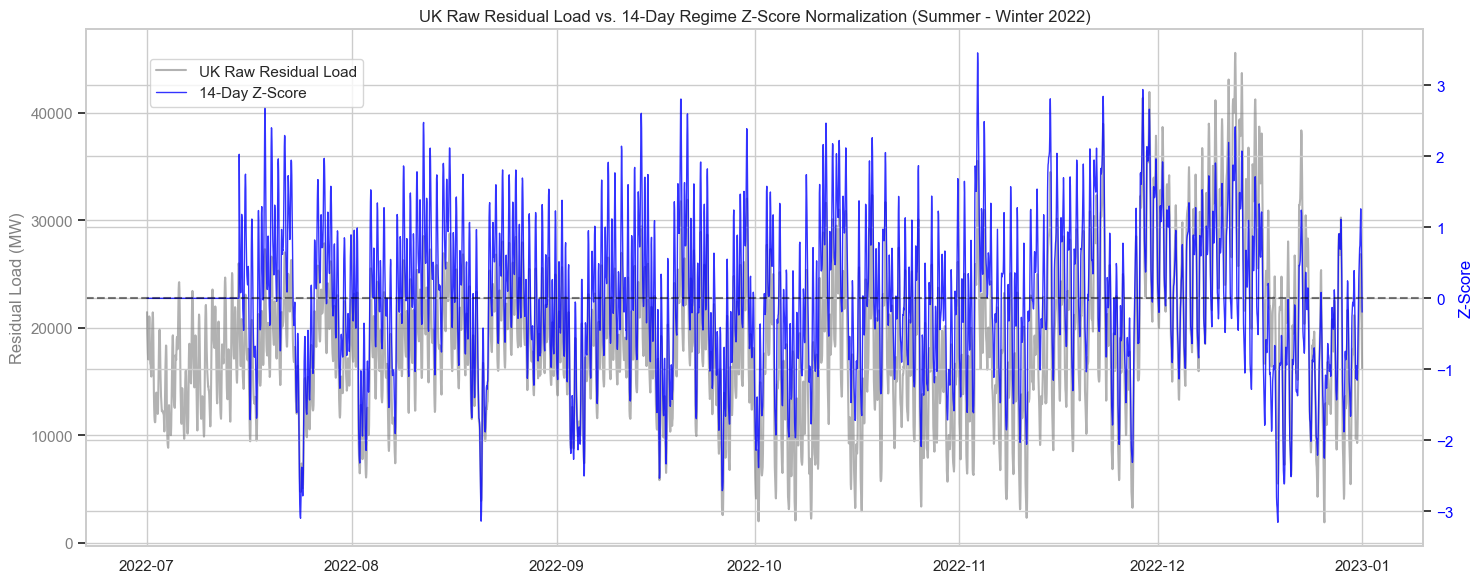

In [25]:
start_dt = '2022-07-01'
end_dt = '2022-12-31'
df_slice = df.loc[start_dt:end_dt]
fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(df_slice.index, df_slice['uk_res_load'], color='grey', alpha=0.6, label='UK Raw Residual Load')
ax1.set_ylabel('Residual Load (MW)', color='grey')
ax1.tick_params(axis='y', labelcolor='grey')
ax2 = ax1.twinx()
ax2.plot(df_slice.index, df_slice['uk_res_load_zscore_14d'], color='blue', linewidth=1, alpha=0.8, label='14-Day Z-Score')
ax2.set_ylabel('Z-Score', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('UK Raw Residual Load vs. 14-Day Regime Z-Score Normalization (Summer - Winter 2022)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1,0.9))
plt.tight_layout()
plt.show()


### Advanced MI Validation & Pruning
We calculate the Mutual Information (MI) regression scores for `X` against `fr_spot` and `uk_spot`, highlighting our custom engineered roster. Any feature not making the Top 30 for either target is flagged for deletion.

In [26]:
# The Roster
engineered_roster = [
    'fr_res_load', 'uk_res_load', 'de_res_load', 'be_res_load', 'nl_res_load', 'it_res_load', 'es_res_load', 
    'dk1_res_load', 'dk2_res_load', 'no1_res_load', 'no2_res_load', 'se1_res_load', 'se2_res_load', 'se3_res_load', 
    'se4_res_load', 'ch_res_load', 'at_res_load', 'cz_res_load', 'pl_res_load', 'hu_res_load', 'sk_res_load', 
    'ro_res_load', 'ie_res_load', 'fr_thermal_floor', 'uk_thermal_floor', 'is_fr_holiday', 'is_uk_holiday',
    'fr_nuclear_shortfall', 'uk_nuclear_shortfall', 'fr_spot_la_lag_168', 'uk_spot_la_lag_168',
    'fr_spot_la_vol_24h', 'fr_spot_la_vol_72h', 'uk_spot_la_vol_24h', 'uk_spot_la_vol_72h',
    'hour', 'dayofweek', 'month',
    'fr_spot_la_asinh', 'uk_spot_la_asinh', 'ch_spot_la_asinh',
    'fr_res_load_ramp_3h', 'uk_res_load_ramp_3h',
    'fr_total_cap_f', 'fr_security_margin', 'fr_scarcity_ratio',
    'uk_total_cap_f', 'uk_security_margin', 'uk_scarcity_ratio',
    'fr_res_load_zscore_14d', 'uk_res_load_zscore_14d'
]
for col in df.columns:
    if col.endswith('_ratio') or col.startswith('is_atc_'):
        if col not in engineered_roster:
            engineered_roster.append(col)
# The MI Math
targets = ['fr_spot', 'uk_spot']
X = df.drop(columns=[c for c in targets if c in df.columns])
X_filled = X.fillna(X.median())
print("================ France Top 50 Features ================")
mi_fr = mutual_info_regression(X_filled, df['fr_spot'].fillna(df['fr_spot'].median()), random_state=42)
mi_fr_series = pd.Series(mi_fr, index=X_filled.columns).sort_values(ascending=False)
fr_top_50 = mi_fr_series.head(50)
for feature, score in fr_top_50.items():
    prefix = '⭐ [ENGINEERED] ' if feature in engineered_roster else ''
    print(f"{prefix}{feature}: {score:.4f}")
print("\n================ UK Top 50 Features ================")
mi_uk = mutual_info_regression(X_filled, df['uk_spot'].fillna(df['uk_spot'].median()), random_state=42)
mi_uk_series = pd.Series(mi_uk, index=X_filled.columns).sort_values(ascending=False)
uk_top_50 = mi_uk_series.head(50)
for feature, score in uk_top_50.items():
    prefix = '⭐ [ENGINEERED] ' if feature in engineered_roster else ''
    print(f"{prefix}{feature}: {score:.4f}")


================ France Top 50 Features ================
fr_spot_la: 1.0030
⭐ [ENGINEERED] fr_spot_la_asinh: 0.9987
⭐ [ENGINEERED] ch_spot_la_asinh: 0.9372
ch_spot_la: 0.9282
⭐ [ENGINEERED] fr_thermal_floor: 0.8864
de_gas: 0.8833
nl_gas: 0.8674
fr_gas: 0.8596
be_spot_la: 0.8595
at_spot_la: 0.8592
⭐ [ENGINEERED] uk_thermal_floor: 0.8410
es_gas: 0.8391
uk_gas: 0.8042
uk_emission: 0.7886
uk_spot_la: 0.7674
⭐ [ENGINEERED] uk_spot_la_asinh: 0.7669
nl_spot_la: 0.7638
⭐ [ENGINEERED] fr_spot_la_lag_168: 0.7306
de_spot_la: 0.7240
⭐ [ENGINEERED] fr_nuclear_shortfall: 0.6968
fr_nuclear_avcap_f: 0.6967
atc_fr-uk-3_f: 0.6965
atc_uk-fr-3_f: 0.6898
fr_gas_avcap_f: 0.6827
atc_uk-fr-1_f: 0.6708
eu_emission: 0.6343
dk1_spot_la: 0.6270
atc_fr-uk-2_f: 0.6210
atc_uk-fr-2_f: 0.6159
⭐ [ENGINEERED] uk_spot_la_lag_168: 0.6082
uk_biomass_avcap_f: 0.5832
uk_nuclear_avcap_f: 0.5671
⭐ [ENGINEERED] uk_nuclear_shortfall: 0.5666
dk2_spot_la: 0.5618
fr_river_temp_rhine_rheinfelden_f: 0.5410
atc_uk-be_f: 0.5255
atc_be-

In [27]:
# Task 3: The Pruning Cell
failed_features = []
fr_top_50_features = fr_top_50.index.tolist()
uk_top_50_features = uk_top_50.index.tolist()
for feature in engineered_roster:
    if feature in X_filled.columns:
        if feature not in fr_top_50_features and feature not in uk_top_50_features:
            failed_features.append(feature)
print(f"\n🗑️ [CANDIDATES FOR DELETION] The following features failed to reach the Top 50 for either target:\n{failed_features}")



🗑️ [CANDIDATES FOR DELETION] The following features failed to reach the Top 50 for either target:
['fr_res_load', 'uk_res_load', 'is_fr_holiday', 'is_uk_holiday', 'hour', 'dayofweek', 'month', 'fr_res_load_ramp_3h', 'uk_res_load_ramp_3h', 'uk_total_cap_f', 'uk_security_margin', 'uk_scarcity_ratio', 'fr_res_load_zscore_14d', 'uk_res_load_zscore_14d', 'is_atc_dk1-uk_f_online', 'is_atc_nl-uk_f_online', 'is_atc_uk-dk1_f_online', 'is_atc_uk-nl_f_online']
